In [16]:
import pandas as pd
import numpy as np

def load_data_from_csv(filename):
    return pd.read_csv(filename)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [17]:
dataset = load_data_from_csv('dataset.csv')

In [41]:
from utils import wordToSequence, generate_classification_labels, german_characters
from functools import partial

max_characters = 20

possible_classes = ['m', 'f', 'n']

def flatten(list_of_lists):
    return [item for sublist in list_of_lists for item in sublist]

def preprocessing(chunk):
    chunk['word'] = chunk['word'].str.lower()
    chunk = chunk[chunk['word'].str.len() < max_characters]
    chunk.dropna(inplace=True)
    chunk['sequence'] = chunk['word'].map(partial(wordToSequence, possible_characters=german_characters, set_length = max_characters))
    chunk['labels'] = chunk['gender'].map(partial(generate_classification_labels, classes=possible_classes))
    chunk['labels'] = chunk['labels'].map(flatten)
    return chunk

dataset = preprocessing(dataset)

dataset.head()


,word,gender,sequence,labels
0,keratin,n,"[10, 4, 17, 0, 19, 8, 13, 0, 0, 0, 0, 0, 0, 0,...","[0, 0, 1]"
1,lactalbumin,n,"[11, 0, 2, 19, 0, 11, 1, 20, 12, 8, 13, 0, 0, ...","[0, 0, 1]"
2,mercaptoethanol,n,"[12, 4, 17, 2, 0, 15, 19, 14, 4, 19, 7, 0, 13,...","[0, 0, 1]"
3,nduja,f,"[13, 3, 20, 9, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[0, 1, 0]"
4,vesta,f,"[21, 4, 18, 19, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0]"


In [43]:
from utils import split_data

train_x, train_y, val_x, val_y, test_x, test_y = split_data(dataset, ['sequence'], ['labels'])

train_y.head()

,labels
56550,"[0, 1, 0]"
267131,"[1, 0, 0]"
67903,"[0, 1, 0]"
162291,"[1, 0, 0]"
238843,"[0, 0, 1]"


In [55]:




def x_to_array(x, column):
    array = np.array(x[column].tolist())
    return tf.cast(array, dtype = tf.float32)


train_x = x_to_array(train_x, 'sequence')
val_x = x_to_array(val_x, 'sequence')
test_x = x_to_array(test_x, 'sequence')

train_y = x_to_array(train_y, 'labels')
val_y = x_to_array(val_y, 'labels')
test_y = x_to_array(test_y, 'labels')

print(np.shape(train_x))
print(np.shape(train_y))

(275926, 20)
(275926, 3)


In [45]:
import importlib
import utils
importlib.reload(utils)

<module 'utils' from 'c:\\Users\\Manu\\OneDrive\\Escritorio\\Python\\NNs-Practice\\utils.py'>

In [46]:
from utils import split_data

train_x, train_y, val_x, val_y, test_x, test_y = split_data(dataset, ['sequence'], ['labels'])


# Fifth Version: LSTMs

In [97]:
learning_rates = [0.02, 0.01, 0.005, 0.001, 0.0003]
epochs = [20, 20, 15, 10, 5]

batch_size = 64

loss = keras.losses.BinaryCrossentropy()
metrics = ["accuracy"]


In [98]:
model = keras.models.Sequential()

model.add(layers.Embedding(len(german_characters), 32, input_length=max_characters))

model.add(layers.Bidirectional(layers.LSTM(128)))

model.add(layers.Dense(64, activation='relu'))

model.add(layers.Dense(32, activation='relu'))

model.add(layers.Dense(3, activation='softmax'))



keras.utils.plot_model(model, to_file='model_plot_lstm1.png', show_shapes=True, show_layer_names=True)

model.summary()


Model: "sequential_14"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_14 (Embedding)    (None, 20, 32)            960       
                                                                 
 bidirectional_10 (Bidirecti  (None, 256)              164864    
 onal)                                                           
                                                                 
 dense_24 (Dense)            (None, 64)                16448     
                                                                 
 dense_25 (Dense)            (None, 32)                2080      
                                                                 
 dense_26 (Dense)            (None, 3)                 99        
                                                                 
Total params: 184,451
Trainable params: 184,451
Non-trainable params: 0
_______________________________________________

In [99]:



histories = []
for l_rate, epochs in zip(learning_rates, epochs):
    optim = keras.optimizers.SGD(learning_rate=l_rate)
    model.compile(loss=loss, optimizer=optim, metrics=metrics)
    history = model.fit(train_x, train_y, batch_size=batch_size, epochs=epochs, validation_data=(val_x, val_y), verbose=2, shuffle=True)
    histories.append(history)

result = model.evaluate(test_x, test_y, batch_size=batch_size, verbose=2)

model.summary()

model.save('model_lstm3.h5')

Epoch 1/20
4312/4312 - 78s - loss: 0.6194 - accuracy: 0.4295 - val_loss: 0.6192 - val_accuracy: 0.4261 - 78s/epoch - 18ms/step
Epoch 2/20
4312/4312 - 71s - loss: 0.6151 - accuracy: 0.4349 - val_loss: 0.6120 - val_accuracy: 0.4500 - 71s/epoch - 17ms/step
Epoch 3/20
4312/4312 - 76s - loss: 0.6055 - accuracy: 0.4686 - val_loss: 0.5998 - val_accuracy: 0.4849 - 76s/epoch - 18ms/step
Epoch 4/20


KeyboardInterrupt: 

In [91]:
histories = utils.merge_histories(histories)



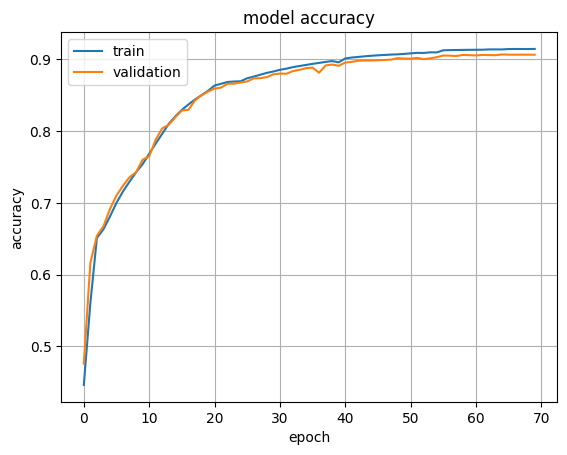

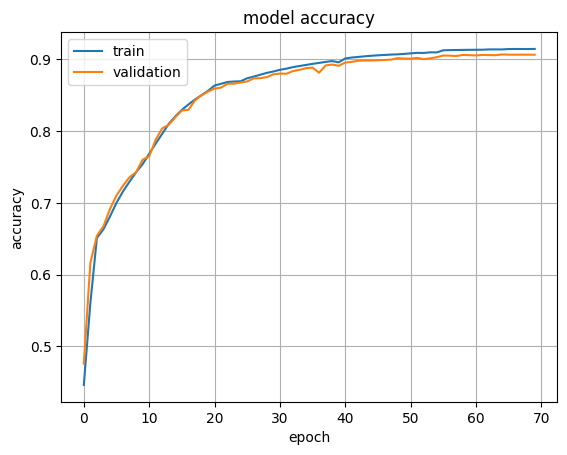

In [93]:
utils.plot_accuracy(utils.slice_history(histories))

### First Attempt:

First attempt with an LSTM:

Changed the input to a sequence based one instead of a one-hot encoding, and lowered the max characters to 20. 

```py
learning_rates = [0.02, 0.01, 0.005, 0.001, 0.0003]
epochs = [10, 10, 10, 20, 10]

batch_size = 32

loss = keras.losses.BinaryCrossentropy()
metrics = ["accuracy"]
```

It's not a very deep network but LSTM layers seem to be much slower than conventional or convolutional ones, so making it deeper would be an issue with my current hardware. 

![model_plot_lstm1.png](plots/model_plot_lstm1.png)  

![fifth_attempt_11.png](plots/fifth_attempt_11.png)

![fifth_attempt_12.png](plots/fifth_attempt_12.png)

Seems to have fairly good accuracy, and also little overfitting. 

## Accuracy: 0.8780 

### Second Attempt:

Changed the LSTM layer to be bidirectional:

```py
model.add(layers.Bidirectional(layers.LSTM(32)))

```

Changed the input to a sequence based one instead of a one-hot encoding, and lowered the max characters to 20. 

```py
learning_rates = [0.02, 0.01, 0.005, 0.001, 0.0003]
epochs = [15, 10, 10, 20, 10]

batch_size = 32

loss = keras.losses.BinaryCrossentropy()
metrics = ["accuracy"]
```


![model_plot_lstm1.png](plots/model_plot_lstm2.png)  

![fifth_attempt_21.png](plots/fifth_attempt_21.png)

![fifth_attempt_22.png](plots/fifth_attempt_22.png)

Significant increase in accuracy, but at the cost of quite a lot more execution time. Realized I was lowering my learning rate too fast, since the accuracy growth had not yet stagnated by the time it was lowered.

## Accuracy: 0.8935

### Third Attempt:

Modified the learning rates per epoch:
```py
learning_rates = [0.02, 0.01, 0.005, 0.001, 0.0003]
epochs = [20, 20, 15, 10, 5]

batch_size = 32

loss = keras.losses.BinaryCrossentropy()
metrics = ["accuracy"]
```
Also tried to add another dense layer but it didn't work out so I cut it short and went back to only one dense layer.

![model_plot_lstm3.png](plots/model_plot_lstm3.png)  

![fifth_attempt_31.png](plots/fifth_attempt_31.png)

![fifth_attempt_32.png](plots/fifth_attempt_32.png)

Significant increase in accuracy again, but overfitting also increased a lot.

# Final Accuracy: 0.9067